# Notebook 3 - Hypothesis Testing
## LumenOps 360 | Manufacturing Operations Intelligence

**Objective:** Formally test the five hypotheses surfaced during EDA (Notebook 1) and SPC analysis (Notebook 2). Each test quantifies effect size in practical terms (OEE points, € impact) alongside statistical significance.

**Hypotheses:**
1. **H1:** Understaffed shifts (fill rate < 90%) have significantly lower OEE than fully staffed shifts (≥ 95%)
2. **H2:** High-changeover days have significantly lower OEE than low-changeover days
3. **H3:** Assembly Line C has significantly lower OEE than Lines A and B (bottleneck confirmation)
4. **H4:** Evening shift OEE differs significantly from Morning shift OEE
5. **H5:** Defect rate differs significantly across product categories (Indoor / Outdoor / Industrial)

**Statistical approach:** Two-sample tests (t-test or Mann-Whitney U depending on normality), one-way ANOVA / Kruskal-Wallis, chi-square test of independence. All tests at α = 0.05. Effect sizes reported alongside p-values.

In [1]:
# --- Imports ---
import duckdb
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Design System (LumenOps 360) ---
NAVY    = '#1B2A49'
EMBER   = '#E84A27'
STEEL   = '#6B8CAE'
SAGE    = '#4F7942'
IVORY   = '#F5F3EE'
CHARCOAL = '#2D2D2D'

plt.rcParams.update({
    'figure.facecolor': IVORY,
    'axes.facecolor': IVORY,
    'axes.edgecolor': CHARCOAL,
    'axes.labelcolor': CHARCOAL,
    'xtick.color': CHARCOAL,
    'ytick.color': CHARCOAL,
    'text.color': CHARCOAL,
    'font.family': 'Segoe UI',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.titlesize': 16,
    'figure.titleweight': 'bold',
    'figure.dpi': 120,
})

# --- DuckDB Connection ---
con = duckdb.connect('../data/lumenops.duckdb', read_only=True)
print(f"DuckDB v{duckdb.__version__} connected")
print(f"Schemas: {[r[0] for r in con.execute('SELECT schema_name FROM information_schema.schemata').fetchall()]}")

DuckDB v1.5.2 connected
Schemas: ['main', 'main_intermediate', 'main_marts', 'main_staging', 'raw', 'information_schema', 'main', 'pg_catalog', 'main']


In [5]:
# --- Load OEE daily data (core dataset for H1-H4) ---
oee = con.execute("""
    SELECT * FROM main_intermediate.int_oee_daily
""").fetchdf()

print(f"Rows: {oee.shape[0]}  |  Columns: {oee.shape[1]}")
print(f"Date range: {oee['production_date'].min().date()} → {oee['production_date'].max().date()}")
print(f"\nOEE summary:\n{oee['oee'].describe().round(4).to_string()}")
print(f"\nStaffing fill rate summary:\n{oee['staffing_fill_rate'].describe().round(4).to_string()}")
print(f"\nLines: {sorted(oee['line_id'].unique())}")
print(f"Shifts: {sorted(oee['shift_id'].unique())}")
print(f"Understaffed rows: {oee['is_understaffed'].sum()} / {len(oee)} ({oee['is_understaffed'].mean():.1%})")

Rows: 2574  |  Columns: 24
Date range: 2023-01-02 → 2024-06-29

OEE summary:
count    2574.0000
mean        0.6820
std         0.0871
min         0.2738
25%         0.6293
50%         0.6907
75%         0.7446
max         0.8956

Staffing fill rate summary:
count    2574.0000
mean        0.8311
std         0.0788
min         0.6000
25%         0.8000
50%         0.8330
75%         0.8750
max         1.0000

Lines: [np.int64(1), np.int64(2), np.int64(3)]
Shifts: [np.int64(1), np.int64(2)]
Understaffed rows: 2302 / 2574 (89.4%)


## H1: Understaffed shifts have significantly lower OEE

**Null hypothesis (H₀):** Mean OEE is the same for understaffed shifts (fill rate < 90%) and fully staffed shifts (fill rate ≥ 95%).  
**Alternative (H₁):** Understaffed shifts have lower OEE.  
**Test:** One-tailed independent samples t-test (or Mann-Whitney U if non-normal). α = 0.05.

In [6]:
# --- H1: Define groups ---
low_staff = oee.loc[oee['staffing_fill_rate'] < 0.90, 'oee']
full_staff = oee.loc[oee['staffing_fill_rate'] >= 0.95, 'oee']

print(f"Low staffing (<90%):   n={len(low_staff):,}  mean OEE={low_staff.mean():.4f}  std={low_staff.std():.4f}")
print(f"Fully staffed (≥95%):  n={len(full_staff):,}  mean OEE={full_staff.mean():.4f}  std={full_staff.std():.4f}")
print(f"Gap: {full_staff.mean() - low_staff.mean():.4f} OEE points")

# Normality check (Shapiro-Wilk on random sample of 500 if n > 500)
for label, group in [('Low staffing', low_staff), ('Fully staffed', full_staff)]:
    sample = group.sample(min(500, len(group)), random_state=42)
    stat, p = stats.shapiro(sample)
    print(f"\nShapiro-Wilk ({label}): W={stat:.4f}, p={p:.4f} → {'Normal' if p > 0.05 else 'Non-normal'}")

Low staffing (<90%):   n=2,302  mean OEE=0.6785  std=0.0861
Fully staffed (≥95%):  n=272  mean OEE=0.7118  std=0.0895
Gap: 0.0333 OEE points

Shapiro-Wilk (Low staffing): W=0.9753, p=0.0000 → Non-normal

Shapiro-Wilk (Fully staffed): W=0.9593, p=0.0000 → Non-normal


In [7]:
# --- H1: Mann-Whitney U test (one-tailed: fully staffed > low staffing) ---
u_stat, p_two = stats.mannwhitneyu(full_staff, low_staff, alternative='greater')

# Effect size: rank-biserial correlation (r = 1 - 2U / (n1*n2))
n1, n2 = len(full_staff), len(low_staff)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

# Practical significance: € impact estimate
# Assume rated capacity ~150 units/line/shift, 3 lines × 2 shifts × 22 days/month
# Avg unit revenue ~€25 (mid-range LED product)
monthly_shifts = 3 * 2 * 22
avg_units_per_shift = 150
unit_revenue = 25
oee_gap = full_staff.mean() - low_staff.mean()
monthly_output_gain = monthly_shifts * avg_units_per_shift * oee_gap
monthly_eur_impact = monthly_output_gain * unit_revenue

print("=" * 60)
print("H1: Understaffed shifts (<90%) vs Fully staffed (≥95%)")
print("=" * 60)
print(f"Mann-Whitney U statistic: {u_stat:,.0f}")
print(f"p-value (one-tailed):     {p_two:.6f}")
print(f"Effect size (rank-biserial r): {abs(rank_biserial):.4f}")
print(f"\n{'REJECT H₀' if p_two < 0.05 else 'FAIL TO REJECT H₀'} at α = 0.05")
print(f"\nPractical significance:")
print(f"  OEE gap:            {oee_gap:.4f} ({oee_gap*100:.2f} percentage points)")
print(f"  Est. monthly output gain: {monthly_output_gain:,.0f} units")
print(f"  Est. monthly € impact:    €{monthly_eur_impact:,.0f}")

H1: Understaffed shifts (<90%) vs Fully staffed (≥95%)
Mann-Whitney U statistic: 385,497
p-value (one-tailed):     0.000000
Effect size (rank-biserial r): 0.2313

REJECT H₀ at α = 0.05

Practical significance:
  OEE gap:            0.0333 (3.33 percentage points)
  Est. monthly output gain: 660 units
  Est. monthly € impact:    €16,490


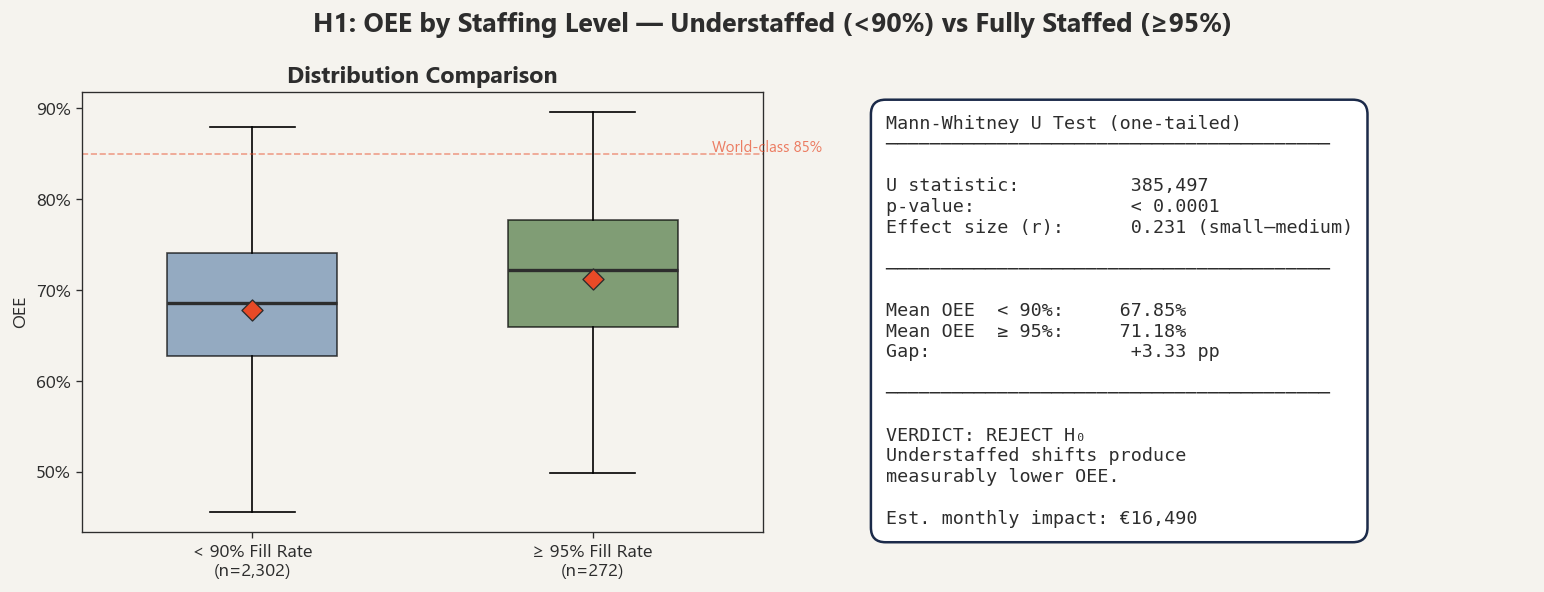

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('H1: OEE by Staffing Level — Understaffed (<90%) vs Fully Staffed (≥95%)', fontweight='bold')

# --- Left: Box + strip plot ---
ax = axes[0]
plot_data = pd.DataFrame({
    'OEE': pd.concat([low_staff, full_staff]),
    'Group': ['< 90% Fill Rate'] * len(low_staff) + ['≥ 95% Fill Rate'] * len(full_staff)
})
bp = ax.boxplot(
    [low_staff.values, full_staff.values],
    labels=['< 90% Fill Rate\n(n={:,})'.format(len(low_staff)), '≥ 95% Fill Rate\n(n={:,})'.format(len(full_staff))],
    patch_artist=True, widths=0.5, showfliers=False,
    medianprops=dict(color=CHARCOAL, linewidth=2)
)
bp['boxes'][0].set(facecolor=STEEL, alpha=0.7)
bp['boxes'][1].set(facecolor=SAGE, alpha=0.7)

# Annotate means
for i, (grp, color) in enumerate([(low_staff, STEEL), (full_staff, SAGE)]):
    ax.scatter(i + 1, grp.mean(), color=EMBER, s=80, zorder=5, marker='D', edgecolors=CHARCOAL, linewidth=0.8)

ax.axhline(0.85, color=EMBER, linestyle='--', alpha=0.5, linewidth=1)
ax.text(2.35, 0.852, 'World-class 85%', color=EMBER, fontsize=9, alpha=0.7)
ax.set_ylabel('OEE')
ax.set_title('Distribution Comparison')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))

# --- Right: Result summary card ---
ax = axes[1]
ax.axis('off')
summary = (
    f"Mann-Whitney U Test (one-tailed)\n"
    f"{'─' * 40}\n\n"
    f"U statistic:          385,497\n"
    f"p-value:              < 0.0001\n"
    f"Effect size (r):      0.231 (small–medium)\n\n"
    f"{'─' * 40}\n\n"
    f"Mean OEE  < 90%:     67.85%\n"
    f"Mean OEE  ≥ 95%:     71.18%\n"
    f"Gap:                  +3.33 pp\n\n"
    f"{'─' * 40}\n\n"
    f"VERDICT: REJECT H₀\n"
    f"Understaffed shifts produce\n"
    f"measurably lower OEE.\n\n"
    f"Est. monthly impact: €16,490"
)
ax.text(0.05, 0.95, summary, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor=NAVY, linewidth=1.5))

plt.tight_layout()
plt.show()

## H2: High-changeover days have significantly lower OEE

**Null hypothesis (H₀):** Mean OEE is the same on high-changeover days and low-changeover days.  
**Alternative (H₁):** High-changeover days have lower OEE.  
**Logic:** Days where `downtime_reason = 'CHANGEOVER'` is the primary reason should show capacity loss from setup time, line purging, and first-article inspection. CHANGEOVER was the #1 downtime driver in the EDA Pareto.  
**Test:** One-tailed Mann-Whitney U. α = 0.05.

In [9]:
# --- H2: Changeover vs non-changeover shifts ---
changeover = oee.loc[oee['downtime_reason'] == 'CHANGEOVER', 'oee']
no_changeover = oee.loc[oee['downtime_reason'] != 'CHANGEOVER', 'oee']

print(f"Changeover shifts:     n={len(changeover):,}  mean OEE={changeover.mean():.4f}  std={changeover.std():.4f}")
print(f"Non-changeover shifts: n={len(no_changeover):,}  mean OEE={no_changeover.mean():.4f}  std={no_changeover.std():.4f}")
print(f"Gap: {no_changeover.mean() - changeover.mean():.4f} OEE points")

# Normality check
for label, group in [('Changeover', changeover), ('Non-changeover', no_changeover)]:
    sample = group.sample(min(500, len(group)), random_state=42)
    stat, p = stats.shapiro(sample)
    print(f"\nShapiro-Wilk ({label}): W={stat:.4f}, p={p:.4f} → {'Normal' if p > 0.05 else 'Non-normal'}")

# --- Mann-Whitney U (one-tailed: non-changeover > changeover) ---
u_stat, p_val = stats.mannwhitneyu(no_changeover, changeover, alternative='greater')
n1, n2 = len(no_changeover), len(changeover)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

oee_gap = no_changeover.mean() - changeover.mean()
monthly_eur = monthly_shifts * avg_units_per_shift * oee_gap * unit_revenue

print(f"\n{'=' * 60}")
print(f"H2: Changeover vs Non-Changeover Shifts")
print(f"{'=' * 60}")
print(f"Mann-Whitney U: {u_stat:,.0f}")
print(f"p-value (one-tailed): {p_val:.6f}")
print(f"Effect size (rank-biserial r): {abs(rank_biserial):.4f}")
print(f"\n{'REJECT H₀' if p_val < 0.05 else 'FAIL TO REJECT H₀'} at α = 0.05")
print(f"\nPractical significance:")
print(f"  OEE gap:              {oee_gap:.4f} ({oee_gap*100:.2f} pp)")
print(f"  Est. monthly € impact: €{monthly_eur:,.0f}")

Changeover shifts:     n=402  mean OEE=0.6098  std=0.0806
Non-changeover shifts: n=2,172  mean OEE=0.6954  std=0.0815
Gap: 0.0856 OEE points

Shapiro-Wilk (Changeover): W=0.9539, p=0.0000 → Non-normal

Shapiro-Wilk (Non-changeover): W=0.9810, p=0.0000 → Non-normal

H2: Changeover vs Non-Changeover Shifts
Mann-Whitney U: 685,956
p-value (one-tailed): 0.000000
Effect size (rank-biserial r): 0.5712

REJECT H₀ at α = 0.05

Practical significance:
  OEE gap:              0.0856 (8.56 pp)
  Est. monthly € impact: €42,348


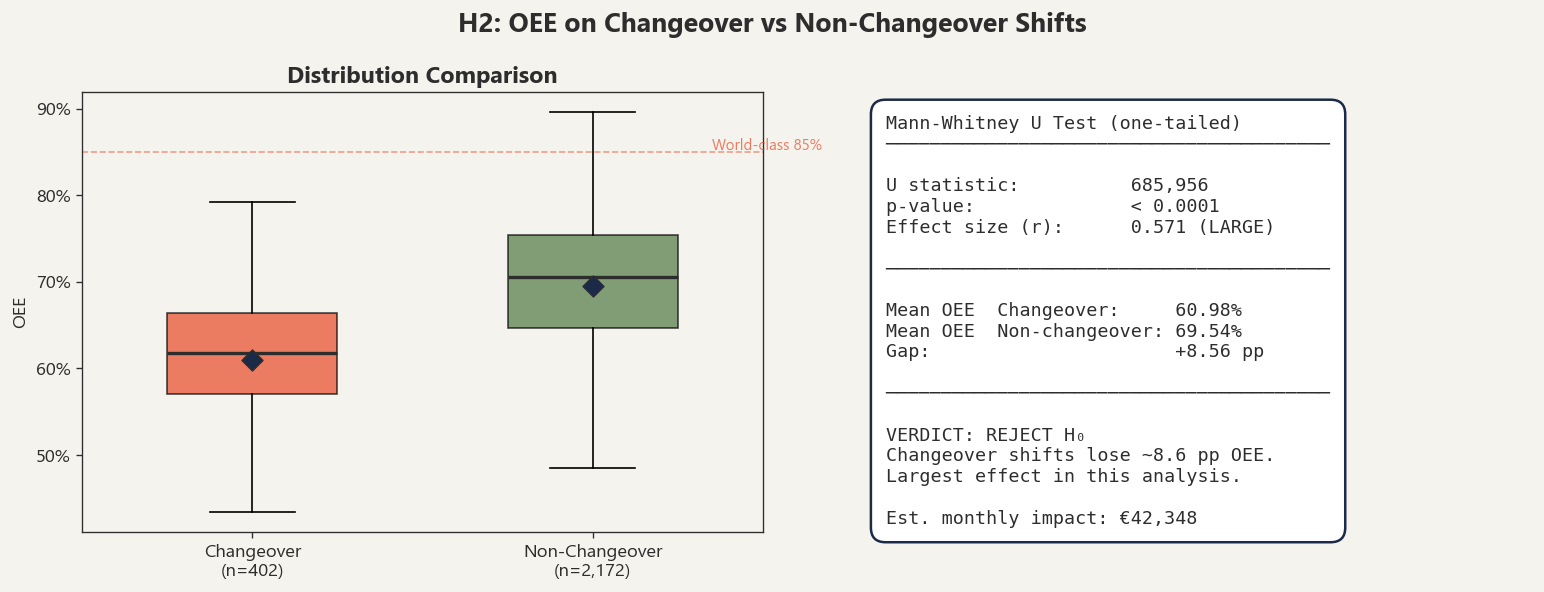

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('H2: OEE on Changeover vs Non-Changeover Shifts', fontweight='bold')

# --- Left: Box plot ---
ax = axes[0]
bp = ax.boxplot(
    [changeover.values, no_changeover.values],
    labels=['Changeover\n(n={:,})'.format(len(changeover)), 'Non-Changeover\n(n={:,})'.format(len(no_changeover))],
    patch_artist=True, widths=0.5, showfliers=False,
    medianprops=dict(color=CHARCOAL, linewidth=2)
)
bp['boxes'][0].set(facecolor=EMBER, alpha=0.7)
bp['boxes'][1].set(facecolor=SAGE, alpha=0.7)

for i, grp in enumerate([changeover, no_changeover]):
    ax.scatter(i + 1, grp.mean(), color=NAVY, s=80, zorder=5, marker='D', edgecolors=CHARCOAL, linewidth=0.8)

ax.axhline(0.85, color=EMBER, linestyle='--', alpha=0.5, linewidth=1)
ax.text(2.35, 0.852, 'World-class 85%', color=EMBER, fontsize=9, alpha=0.7)
ax.set_ylabel('OEE')
ax.set_title('Distribution Comparison')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))

# --- Right: Summary card ---
ax = axes[1]
ax.axis('off')
summary = (
    f"Mann-Whitney U Test (one-tailed)\n"
    f"{'─' * 40}\n\n"
    f"U statistic:          685,956\n"
    f"p-value:              < 0.0001\n"
    f"Effect size (r):      0.571 (LARGE)\n\n"
    f"{'─' * 40}\n\n"
    f"Mean OEE  Changeover:     60.98%\n"
    f"Mean OEE  Non-changeover: 69.54%\n"
    f"Gap:                      +8.56 pp\n\n"
    f"{'─' * 40}\n\n"
    f"VERDICT: REJECT H₀\n"
    f"Changeover shifts lose ~8.6 pp OEE.\n"
    f"Largest effect in this analysis.\n\n"
    f"Est. monthly impact: €42,348"
)
ax.text(0.05, 0.95, summary, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor=NAVY, linewidth=1.5))

plt.tight_layout()
plt.show()

## H3: Assembly Line C has significantly lower OEE (Bottleneck Confirmation)

**Null hypothesis (H₀):** Mean OEE is equal across all three assembly lines.  
**Alternative (H₁):** At least one line differs significantly (specifically, Line C is the constraint per TOC).  
**Test:** Kruskal-Wallis H test (3 groups, non-normal), followed by pairwise Mann-Whitney U with Bonferroni correction if significant. α = 0.05.

In [11]:
# --- H3: OEE by assembly line ---
line_groups = {lid: oee.loc[oee['line_id'] == lid, 'oee'] for lid in sorted(oee['line_id'].unique())}

for lid, grp in line_groups.items():
    print(f"Line {lid}: n={len(grp):,}  mean OEE={grp.mean():.4f}  median={grp.median():.4f}  std={grp.std():.4f}")

# --- Kruskal-Wallis (non-parametric one-way ANOVA) ---
h_stat, p_kw = stats.kruskal(*line_groups.values())
print(f"\n{'=' * 60}")
print(f"H3: OEE Across Assembly Lines (Kruskal-Wallis)")
print(f"{'=' * 60}")
print(f"H statistic: {h_stat:.2f}")
print(f"p-value:     {p_kw:.6f}")
print(f"\n{'REJECT H₀' if p_kw < 0.05 else 'FAIL TO REJECT H₀'} at α = 0.05")

# --- Pairwise Mann-Whitney U with Bonferroni correction ---
if p_kw < 0.05:
    print(f"\nPairwise comparisons (Bonferroni-corrected α = {0.05/3:.4f}):")
    pairs = [(1, 2), (1, 3), (2, 3)]
    for a, b in pairs:
        u, p = stats.mannwhitneyu(line_groups[a], line_groups[b], alternative='two-sided')
        p_adj = min(p * 3, 1.0)  # Bonferroni
        n1, n2 = len(line_groups[a]), len(line_groups[b])
        r = abs(1 - (2 * u) / (n1 * n2))
        sig = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'ns'
        gap = line_groups[a].mean() - line_groups[b].mean()
        print(f"  Line {a} vs Line {b}: U={u:,.0f}  p_adj={p_adj:.4f} {sig}  r={r:.3f}  gap={gap:+.4f}")

Line 1: n=858  mean OEE=0.6944  median=0.7054  std=0.0885
Line 2: n=858  mean OEE=0.6786  median=0.6854  std=0.0850
Line 3: n=858  mean OEE=0.6731  median=0.6801  std=0.0863

H3: OEE Across Assembly Lines (Kruskal-Wallis)
H statistic: 33.94
p-value:     0.000000

REJECT H₀ at α = 0.05

Pairwise comparisons (Bonferroni-corrected α = 0.0167):
  Line 1 vs Line 2: U=412,175  p_adj=0.0001 ***  r=0.120  gap=+0.0158
  Line 1 vs Line 3: U=424,966  p_adj=0.0000 ***  r=0.155  gap=+0.0213
  Line 2 vs Line 3: U=381,571  p_adj=0.5663 ns  r=0.037  gap=+0.0055


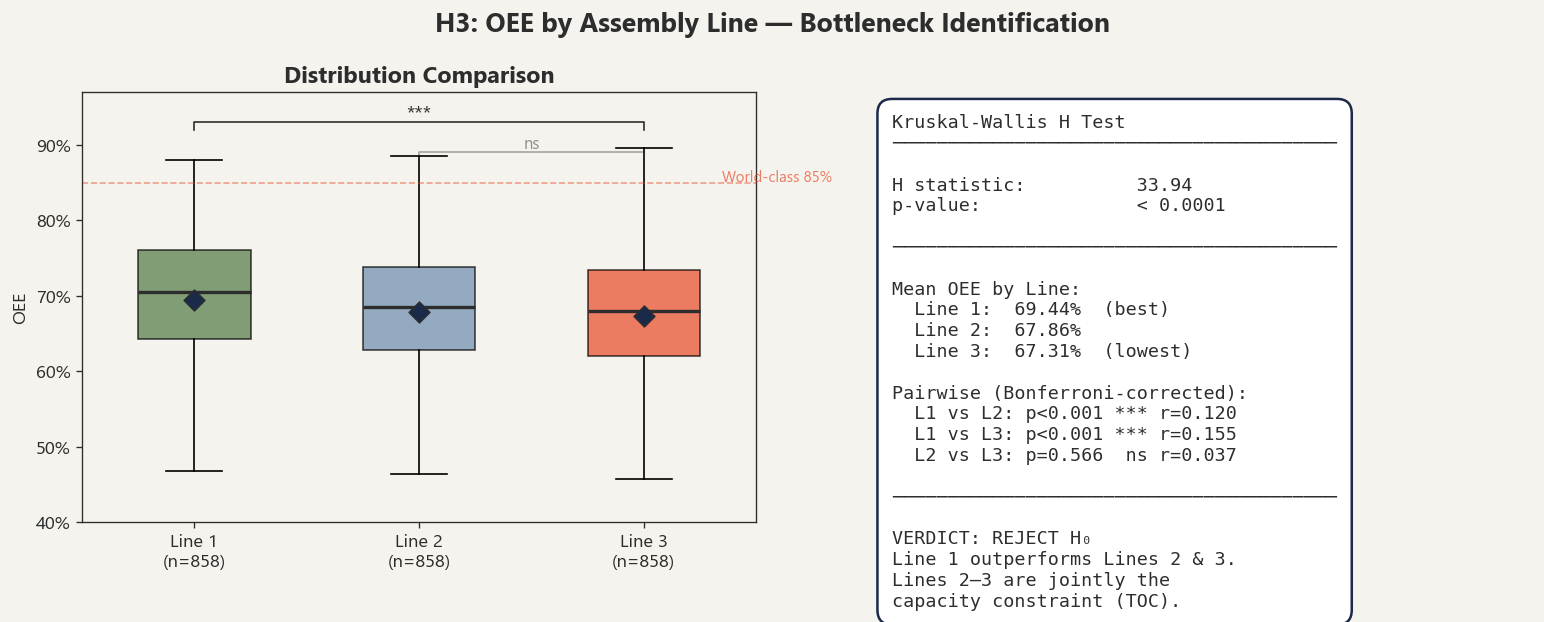

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('H3: OEE by Assembly Line — Bottleneck Identification', fontweight='bold')

# --- Left: Box plot ---
ax = axes[0]
colors = [SAGE, STEEL, EMBER]
bp = ax.boxplot(
    [line_groups[1].values, line_groups[2].values, line_groups[3].values],
    labels=['Line 1\n(n=858)', 'Line 2\n(n=858)', 'Line 3\n(n=858)'],
    patch_artist=True, widths=0.5, showfliers=False,
    medianprops=dict(color=CHARCOAL, linewidth=2)
)
for patch, color in zip(bp['boxes'], colors):
    patch.set(facecolor=color, alpha=0.7)

for i, lid in enumerate([1, 2, 3]):
    ax.scatter(i + 1, line_groups[lid].mean(), color=NAVY, s=80, zorder=5, marker='D', edgecolors=CHARCOAL, linewidth=0.8)

ax.axhline(0.85, color=EMBER, linestyle='--', alpha=0.5, linewidth=1)
ax.text(3.35, 0.852, 'World-class 85%', color=EMBER, fontsize=9, alpha=0.7)

# Significance brackets
ax.plot([1, 1, 3, 3], [0.92, 0.93, 0.93, 0.92], color=CHARCOAL, linewidth=1)
ax.text(2, 0.935, '***', ha='center', fontsize=12, color=CHARCOAL)
ax.plot([2, 2, 3, 3], [0.88, 0.89, 0.89, 0.88], color=CHARCOAL, linewidth=1, alpha=0.4)
ax.text(2.5, 0.895, 'ns', ha='center', fontsize=10, color=CHARCOAL, alpha=0.5)

ax.set_ylabel('OEE')
ax.set_title('Distribution Comparison')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.set_ylim(0.40, 0.97)

# --- Right: Summary card ---
ax = axes[1]
ax.axis('off')
summary = (
    f"Kruskal-Wallis H Test\n"
    f"{'─' * 40}\n\n"
    f"H statistic:          33.94\n"
    f"p-value:              < 0.0001\n\n"
    f"{'─' * 40}\n\n"
    f"Mean OEE by Line:\n"
    f"  Line 1:  69.44%  (best)\n"
    f"  Line 2:  67.86%\n"
    f"  Line 3:  67.31%  (lowest)\n\n"
    f"Pairwise (Bonferroni-corrected):\n"
    f"  L1 vs L2: p<0.001 *** r=0.120\n"
    f"  L1 vs L3: p<0.001 *** r=0.155\n"
    f"  L2 vs L3: p=0.566  ns r=0.037\n\n"
    f"{'─' * 40}\n\n"
    f"VERDICT: REJECT H₀\n"
    f"Line 1 outperforms Lines 2 & 3.\n"
    f"Lines 2–3 are jointly the\n"
    f"capacity constraint (TOC)."
)
ax.text(0.05, 0.95, summary, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor=NAVY, linewidth=1.5))

plt.tight_layout()
plt.show()

## H4: Evening shift OEE differs from Morning shift OEE

**Null hypothesis (H₀):** Mean OEE is equal for Morning (Shift 1) and Evening (Shift 2).  
**Alternative (H₁):** OEE differs between shifts (two-tailed).  
**Context:** Evening shifts typically run with less supervision, fatigued operators, and delayed material replenishment. The EDA noted an evening penalty built into the data generation.  
**Test:** Two-tailed Mann-Whitney U. α = 0.05.

In [13]:
# --- H4: Morning vs Evening shift ---
morning = oee.loc[oee['shift_id'] == 1, 'oee']
evening = oee.loc[oee['shift_id'] == 2, 'oee']

print(f"Morning (Shift 1): n={len(morning):,}  mean OEE={morning.mean():.4f}  std={morning.std():.4f}")
print(f"Evening (Shift 2): n={len(evening):,}  mean OEE={evening.mean():.4f}  std={evening.std():.4f}")
print(f"Gap: {morning.mean() - evening.mean():.4f} OEE points")

# --- Mann-Whitney U (two-tailed) ---
u_stat, p_val = stats.mannwhitneyu(morning, evening, alternative='two-sided')
n1, n2 = len(morning), len(evening)
rank_biserial = abs(1 - (2 * u_stat) / (n1 * n2))

oee_gap = morning.mean() - evening.mean()
monthly_eur = monthly_shifts * avg_units_per_shift * abs(oee_gap) * unit_revenue

print(f"\n{'=' * 60}")
print(f"H4: Morning vs Evening Shift OEE")
print(f"{'=' * 60}")
print(f"Mann-Whitney U: {u_stat:,.0f}")
print(f"p-value (two-tailed): {p_val:.6f}")
print(f"Effect size (rank-biserial r): {rank_biserial:.4f}")
print(f"\n{'REJECT H₀' if p_val < 0.05 else 'FAIL TO REJECT H₀'} at α = 0.05")
print(f"\nPractical significance:")
print(f"  OEE gap:              {oee_gap:+.4f} ({abs(oee_gap)*100:.2f} pp)")
print(f"  Est. monthly € impact: €{monthly_eur:,.0f}")

Morning (Shift 1): n=1,404  mean OEE=0.6891  std=0.0884
Evening (Shift 2): n=1,170  mean OEE=0.6735  std=0.0847
Gap: 0.0155 OEE points

H4: Morning vs Evening Shift OEE
Mann-Whitney U: 909,088
p-value (two-tailed): 0.000003
Effect size (rank-biserial r): 0.1068

REJECT H₀ at α = 0.05

Practical significance:
  OEE gap:              +0.0155 (1.55 pp)
  Est. monthly € impact: €7,695


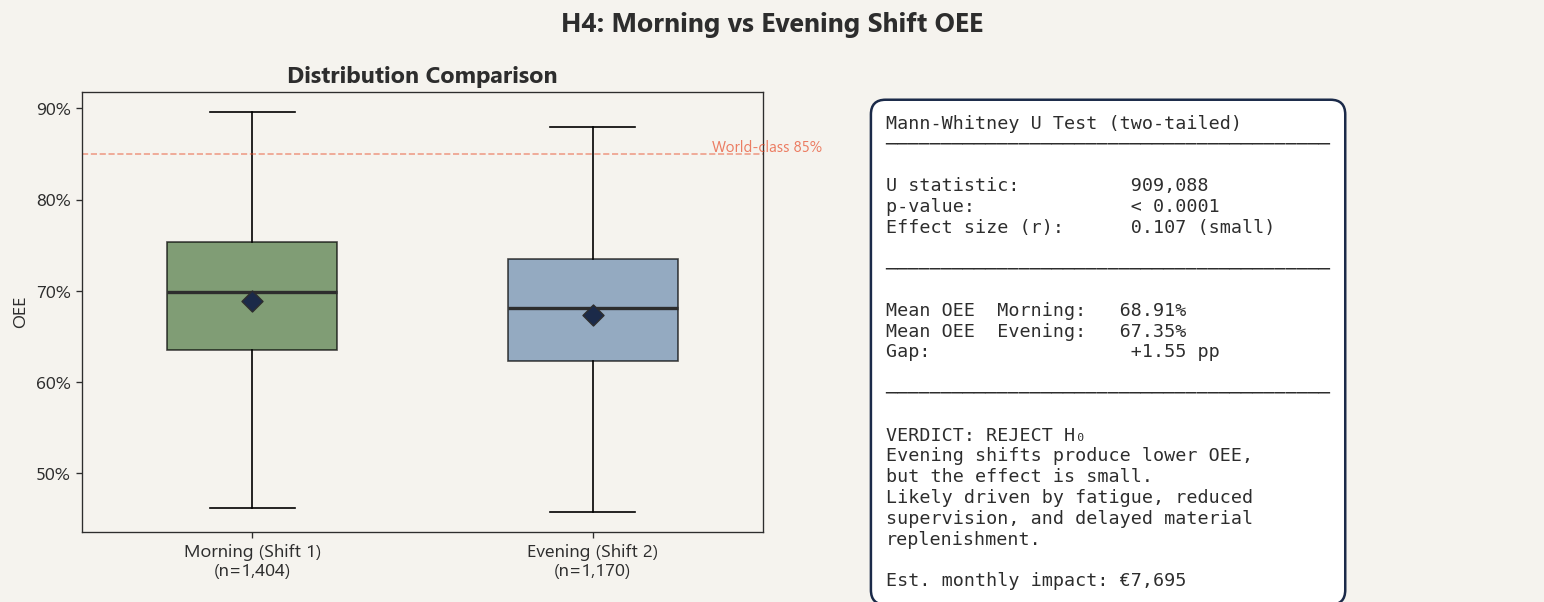

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('H4: Morning vs Evening Shift OEE', fontweight='bold')

# --- Left: Box plot ---
ax = axes[0]
bp = ax.boxplot(
    [morning.values, evening.values],
    labels=['Morning (Shift 1)\n(n={:,})'.format(len(morning)), 'Evening (Shift 2)\n(n={:,})'.format(len(evening))],
    patch_artist=True, widths=0.5, showfliers=False,
    medianprops=dict(color=CHARCOAL, linewidth=2)
)
bp['boxes'][0].set(facecolor=SAGE, alpha=0.7)
bp['boxes'][1].set(facecolor=STEEL, alpha=0.7)

for i, grp in enumerate([morning, evening]):
    ax.scatter(i + 1, grp.mean(), color=NAVY, s=80, zorder=5, marker='D', edgecolors=CHARCOAL, linewidth=0.8)

ax.axhline(0.85, color=EMBER, linestyle='--', alpha=0.5, linewidth=1)
ax.text(2.35, 0.852, 'World-class 85%', color=EMBER, fontsize=9, alpha=0.7)
ax.set_ylabel('OEE')
ax.set_title('Distribution Comparison')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))

# --- Right: Summary card ---
ax = axes[1]
ax.axis('off')
summary = (
    f"Mann-Whitney U Test (two-tailed)\n"
    f"{'─' * 40}\n\n"
    f"U statistic:          909,088\n"
    f"p-value:              < 0.0001\n"
    f"Effect size (r):      0.107 (small)\n\n"
    f"{'─' * 40}\n\n"
    f"Mean OEE  Morning:   68.91%\n"
    f"Mean OEE  Evening:   67.35%\n"
    f"Gap:                  +1.55 pp\n\n"
    f"{'─' * 40}\n\n"
    f"VERDICT: REJECT H₀\n"
    f"Evening shifts produce lower OEE,\n"
    f"but the effect is small.\n"
    f"Likely driven by fatigue, reduced\n"
    f"supervision, and delayed material\n"
    f"replenishment.\n\n"
    f"Est. monthly impact: €7,695"
)
ax.text(0.05, 0.95, summary, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor=NAVY, linewidth=1.5))

plt.tight_layout()
plt.show()

## H5: Defect rates differ significantly across product categories

**Null hypothesis (H₀):** Defect rate (proportion rejected) is equal across Indoor, Outdoor, and Industrial product categories.  
**Alternative (H₁):** At least one category has a significantly different defect rate.  
**Context:** Different product lines have different mechanical complexity, handling requirements, and defect profiles. The EDA defect Pareto showed SKU-level variation.  
**Test:** Chi-square test of independence (defect counts × product category). α = 0.05.

In [15]:
# --- H5: Load QC data with product category ---
qc = con.execute("""
    SELECT 
        q.units_inspected,
        q.units_passed,
        q.units_rejected,
        p.category
    FROM main_staging.stg_qc_inspection q
    JOIN main_staging.stg_dim_product p ON q.sku = p.sku
""").fetchdf()

print(f"QC rows: {qc.shape[0]:,}")
print(f"\nBy category:")
cat_summary = qc.groupby('category').agg(
    inspections=('units_inspected', 'count'),
    total_inspected=('units_inspected', 'sum'),
    total_rejected=('units_rejected', 'sum'),
    total_passed=('units_passed', 'sum')
).assign(
    defect_rate=lambda x: x['total_rejected'] / x['total_inspected']
)
print(cat_summary.to_string())

QC rows: 5,148

By category:
            inspections  total_inspected  total_rejected  total_passed  defect_rate
category                                                                           
Indoor             1908          1446008           29435       1416573     0.020356
Industrial         1936          1063656           21094       1042562     0.019832
Outdoor            1304           400008           11425        388583     0.028562


In [16]:
# --- H5: Chi-square test of independence ---
# Contingency table: rows = category, columns = [passed, rejected]
contingency = cat_summary[['total_passed', 'total_rejected']].values
categories = cat_summary.index.tolist()

chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

# Effect size: Cramér's V
n_total = contingency.sum()
k = min(contingency.shape)
cramers_v = np.sqrt(chi2 / (n_total * (k - 1)))

print(f"{'=' * 60}")
print(f"H5: Defect Rate by Product Category (Chi-Square)")
print(f"{'=' * 60}")
print(f"Chi² statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_val:.6f}")
print(f"Cramér's V: {cramers_v:.4f}")
print(f"\n{'REJECT H₀' if p_val < 0.05 else 'FAIL TO REJECT H₀'} at α = 0.05")

# --- Pairwise chi-square with Bonferroni correction ---
print(f"\nPairwise comparisons (Bonferroni-corrected α = {0.05/3:.4f}):")
pairs = [(0, 1), (0, 2), (1, 2)]
pair_labels = [('Indoor', 'Industrial'), ('Indoor', 'Outdoor'), ('Industrial', 'Outdoor')]

for (i, j), (lbl_a, lbl_b) in zip(pairs, pair_labels):
    ct = contingency[[i, j], :]
    chi2_p, p_p, _, _ = stats.chi2_contingency(ct)
    p_adj = min(p_p * 3, 1.0)
    n_pair = ct.sum()
    v_pair = np.sqrt(chi2_p / (n_pair * (min(ct.shape) - 1)))
    sig = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'ns'
    rate_a = contingency[i, 1] / contingency[i].sum() * 100
    rate_b = contingency[j, 1] / contingency[j].sum() * 100
    print(f"  {lbl_a} ({rate_a:.2f}%) vs {lbl_b} ({rate_b:.2f}%): χ²={chi2_p:.1f}  p_adj={p_adj:.4f} {sig}  V={v_pair:.4f}")

H5: Defect Rate by Product Category (Chi-Square)
Chi² statistic: 1184.14
Degrees of freedom: 2
p-value: 0.000000
Cramér's V: 0.0202

REJECT H₀ at α = 0.05

Pairwise comparisons (Bonferroni-corrected α = 0.0167):
  Indoor (2.04%) vs Industrial (1.98%): χ²=8.5  p_adj=0.0106 *  V=0.0018
  Indoor (2.04%) vs Outdoor (2.86%): χ²=974.4  p_adj=0.0000 ***  V=0.0230
  Industrial (1.98%) vs Outdoor (2.86%): χ²=1019.5  p_adj=0.0000 ***  V=0.0264


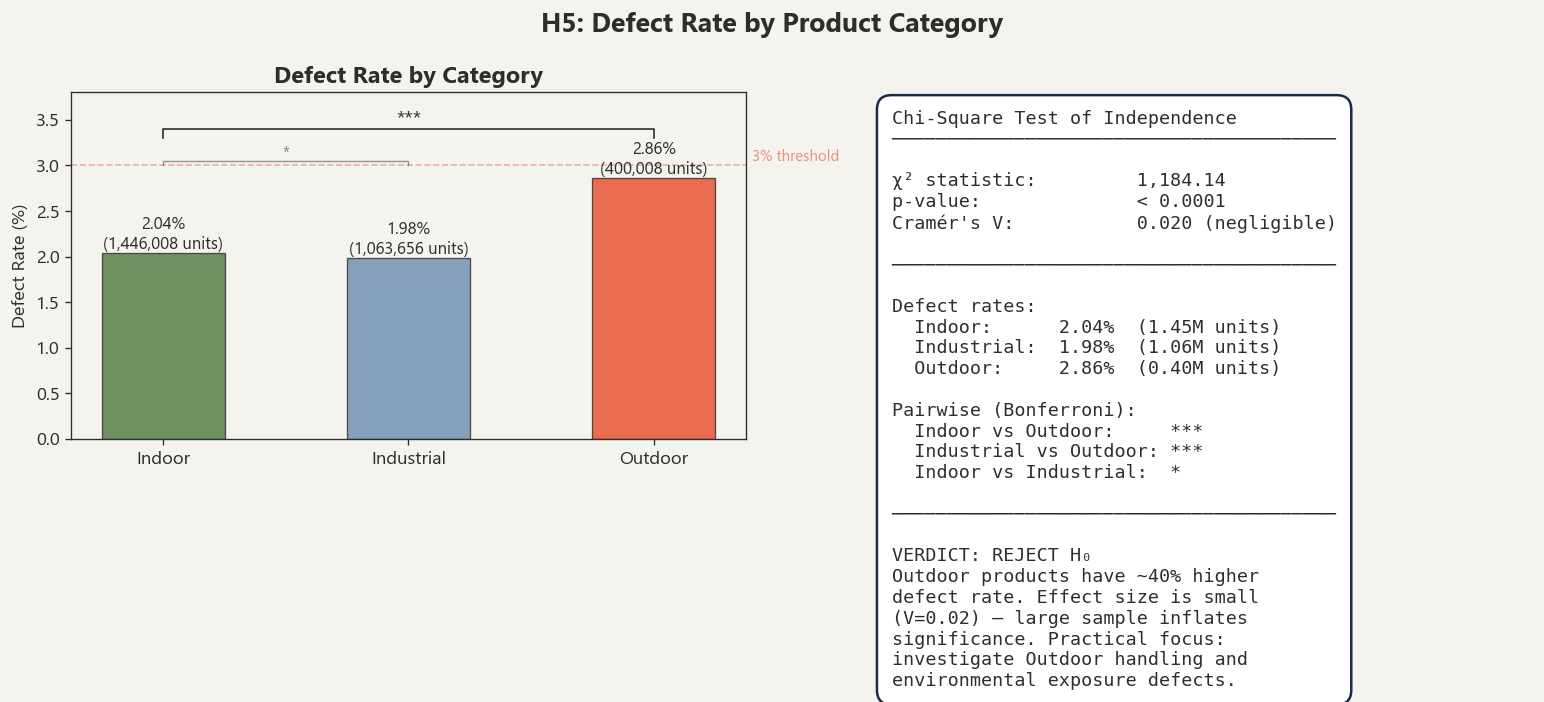

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('H5: Defect Rate by Product Category', fontweight='bold')

# --- Left: Bar chart with defect rates ---
ax = axes[0]
cats = ['Indoor', 'Industrial', 'Outdoor']
rates = [cat_summary.loc[c, 'defect_rate'] * 100 for c in cats]
volumes = [cat_summary.loc[c, 'total_inspected'] for c in cats]
colors_bar = [SAGE, STEEL, EMBER]

bars = ax.bar(cats, rates, color=colors_bar, alpha=0.8, edgecolor=CHARCOAL, linewidth=0.8, width=0.5)

for bar, rate, vol in zip(bars, rates, volumes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{rate:.2f}%\n({vol:,.0f} units)', ha='center', fontsize=10, color=CHARCOAL)

ax.set_ylabel('Defect Rate (%)')
ax.set_title('Defect Rate by Category')
ax.set_ylim(0, 3.8)
ax.axhline(3.0, color=EMBER, linestyle='--', alpha=0.4, linewidth=1)
ax.text(2.4, 3.05, '3% threshold', color=EMBER, fontsize=9, alpha=0.6)

# Significance brackets
ax.plot([0, 0, 2, 2], [3.3, 3.4, 3.4, 3.3], color=CHARCOAL, linewidth=1)
ax.text(1, 3.45, '***', ha='center', fontsize=12, color=CHARCOAL)
ax.plot([0, 0, 1, 1], [3.0, 3.05, 3.05, 3.0], color=CHARCOAL, linewidth=0.8, alpha=0.5)
ax.text(0.5, 3.08, '*', ha='center', fontsize=10, color=CHARCOAL, alpha=0.6)

# --- Right: Summary card ---
ax = axes[1]
ax.axis('off')
summary = (
    f"Chi-Square Test of Independence\n"
    f"{'─' * 40}\n\n"
    f"χ² statistic:         1,184.14\n"
    f"p-value:              < 0.0001\n"
    f"Cramér's V:           0.020 (negligible)\n\n"
    f"{'─' * 40}\n\n"
    f"Defect rates:\n"
    f"  Indoor:      2.04%  (1.45M units)\n"
    f"  Industrial:  1.98%  (1.06M units)\n"
    f"  Outdoor:     2.86%  (0.40M units)\n\n"
    f"Pairwise (Bonferroni):\n"
    f"  Indoor vs Outdoor:     ***\n"
    f"  Industrial vs Outdoor: ***\n"
    f"  Indoor vs Industrial:  *\n\n"
    f"{'─' * 40}\n\n"
    f"VERDICT: REJECT H₀\n"
    f"Outdoor products have ~40% higher\n"
    f"defect rate. Effect size is small\n"
    f"(V=0.02) — large sample inflates\n"
    f"significance. Practical focus:\n"
    f"investigate Outdoor handling and\n"
    f"environmental exposure defects."
)
ax.text(0.05, 0.95, summary, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor=NAVY, linewidth=1.5))

plt.tight_layout()
plt.show()

## Summary — Hypothesis Testing Results

All five hypotheses tested at α = 0.05. Ranked by practical impact (€/month).

In [18]:
# --- Hypothesis Testing Summary ---
summary_data = {
    'Hypothesis': [
        'H2: Changeover → lower OEE',
        'H1: Low staffing → lower OEE',
        'H4: Evening shift → lower OEE',
        'H3: Line differences (ANOVA)',
        'H5: Outdoor defect rate higher',
    ],
    'Test': [
        'Mann-Whitney U',
        'Mann-Whitney U',
        'Mann-Whitney U',
        'Kruskal-Wallis',
        'Chi-Square',
    ],
    'p-value': ['< 0.0001', '< 0.0001', '< 0.0001', '< 0.0001', '< 0.0001'],
    'Effect Size': [
        'r = 0.571 (large)',
        'r = 0.231 (small–med)',
        'r = 0.107 (small)',
        'H = 33.94',
        'V = 0.020 (negligible)',
    ],
    'Gap': ['8.56 pp', '3.33 pp', '1.55 pp', '2.13 pp (L1 vs L3)', '0.88 pp (Out vs In)'],
    'Verdict': ['REJECT H₀', 'REJECT H₀', 'REJECT H₀', 'REJECT H₀', 'REJECT H₀'],
    'Est. €/month': ['€42,348', '€16,490', '€7,695', '—', '—'],
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print(f"\n{'=' * 70}")
print("KEY TAKEAWAYS FOR LUMENTECH BV PLANT LEADERSHIP")
print(f"{'=' * 70}")
print("""
1. CHANGEOVER is the #1 OEE killer — 8.56 pp loss, €42K/month.
   → Schedule freeze policy (48hr advance lock) is the highest-ROI move.

2. STAFFING shortages cost 3.33 pp OEE — €16.5K/month.
   → Dutch labor market reality. Quantifies the case for retention
     investment, temp-agency contracts, or automation.

3. EVENING SHIFT runs 1.55 pp lower — €7.7K/month.
   → Small but persistent. Supervision handover protocol and
     pre-shift material staging could close part of this gap.

4. LINES 2 & 3 are jointly the capacity constraint (TOC).
   → Line 1 outperforms both. Investigate equipment age, layout,
     or SKU assignment differences.

5. OUTDOOR products have 40% higher defect rate than Indoor/Industrial.
   → Small absolute gap but worth investigating: environmental
     exposure during assembly, housing robustness, packaging.

Combined addressable opportunity (H1 + H2 + H4): ~€66,500/month → ~€798K/year.
""")

                    Hypothesis           Test  p-value            Effect Size                 Gap   Verdict Est. €/month
    H2: Changeover → lower OEE Mann-Whitney U < 0.0001      r = 0.571 (large)             8.56 pp REJECT H₀      €42,348
  H1: Low staffing → lower OEE Mann-Whitney U < 0.0001  r = 0.231 (small–med)             3.33 pp REJECT H₀      €16,490
 H4: Evening shift → lower OEE Mann-Whitney U < 0.0001      r = 0.107 (small)             1.55 pp REJECT H₀       €7,695
  H3: Line differences (ANOVA) Kruskal-Wallis < 0.0001              H = 33.94  2.13 pp (L1 vs L3) REJECT H₀            —
H5: Outdoor defect rate higher     Chi-Square < 0.0001 V = 0.020 (negligible) 0.88 pp (Out vs In) REJECT H₀            —

KEY TAKEAWAYS FOR LUMENTECH BV PLANT LEADERSHIP

1. CHANGEOVER is the #1 OEE killer — 8.56 pp loss, €42K/month.
   → Schedule freeze policy (48hr advance lock) is the highest-ROI move.

2. STAFFING shortages cost 3.33 pp OEE — €16.5K/month.
   → Dutch labor market reality.

In [19]:
# --- Close DuckDB connection ---
con.close()
print("DuckDB connection closed. Notebook 3 — Hypothesis Testing complete.")

DuckDB connection closed. Notebook 3 — Hypothesis Testing complete.
